In [344]:
# Import necessary libraries
import math
import numpy as np
from matplotlib.ticker import EngFormatter

In [345]:
# General parameters 

eta = 0.85    # Efficiency of the converter
P_OUT = 110  # Output power in watts
P_IN = P_OUT/eta  # Input power in watts
print(f"Input Power (P_IN): {EngFormatter(unit='W').format_data(P_IN)}")    
V_IN_min = 110  # Minimum input voltage in volts
V_IN_max = 132  # Maximum input voltage in volts
Vout = 45  # Output voltage in volts
f_sw = 110e3  # Switching frequency in hertz
RL = 18 # Load resistance in ohms
V_IN_rms_typical = 120  # Typical RMS input voltage in volts
Vref = 5 # Reference voltage from the controller in volts

V_bulk_typical = (np.sqrt(2)*V_IN_rms_typical-2*0.7)  # Estimated bulk voltage in volts
print(f"Estimated Typical Bulk Voltage (V_bulk_typical): {EngFormatter(unit='V').format_data(V_bulk_typical)}")

Rcs = 0.656 # Current sense resistor in ohms. Actualizar si algo


Input Power (P_IN): 129.412 W
Estimated Typical Bulk Voltage (V_bulk_typical): 168.306 V


# Python functs for values calculation

### Bulk Capacitor

In [346]:
def calc_cin(P_IN, V_BULK_min, V_IN_min, f_LINE_min): # C_bulk
    return (2 * P_IN * (0.25 + (1 / math.pi) * math.asin(V_BULK_min / (math.sqrt(2) * V_IN_min)))) / ((2 * V_IN_min**2 - V_BULK_min**2) * f_LINE_min)

In [347]:
# Minimum bulk voltage in volts DC/prom --> Realmente toca diseñar primero otras etapas para definir este valor,
#pero se puede usar un valor estimado para asegurar que el bulk voltage no caiga por debajo de un cierto nivel durante la operación. 
# En este caso, se ha considerado una caída de 2 diodos (2*0.7V) y un margen de seguridad del 10% (0.9) para obtener un valor estimado del 
# voltaje mínimo del bulk.
V_BULK_min = (np.sqrt(2)*V_IN_min-2*0.7)*0.9
print(f"Estimated Minimum Bulk Voltage (V_BULK_min): {EngFormatter(unit='V').format_data(V_BULK_min)}")
f_LINE_min = 50  # Minimum line frequency in Hz

# Calculate the required bulk capacitance
C_bulk = calc_cin(P_IN, V_BULK_min, V_IN_min, f_LINE_min)
print(f"Required Bulk Capacitance (C_bulk): {EngFormatter(unit='F').format_data(C_bulk)}")

Estimated Minimum Bulk Voltage (V_BULK_min): 138.747 V
Required Bulk Capacitance (C_bulk): 628.205 µF


### Transformer turns ratio and Maximun Duty Cycle


In [348]:
def calc_vbulk_max(V_IN_max):
    return np.sqrt(2) * V_IN_max

def calc_vreflected(V_DS_rated, V_BULK_max):
    return 0.8 * (V_DS_rated - 1.3 * V_BULK_max)

def calc_nps(V_REFLECTED, V_OUT):
    return V_REFLECTED / V_OUT

def calc_npa(N_PS, V_OUT, V_BIAS):
    return N_PS * (V_OUT / V_BIAS)

def calc_vdiode(V_BULK_max, N_PS, V_OUT):
    return (V_BULK_max / N_PS) + V_OUT

def calc_dmax(N_PS, V_OUT, V_F, V_BULK_min):
    return (N_PS * (V_OUT + V_F)) / (V_BULK_min + N_PS * (V_OUT + V_F))


In [349]:
# Define parameters

Vbulk_max = calc_vbulk_max(V_IN_max)

V_DS_rated = 400  # Rated drain-source voltage of the MOSFET in volts
V_reflected = calc_vreflected(V_DS_rated, Vbulk_max)

Nps = calc_nps(V_reflected, Vout)  

print(f"Maximum Bulk Voltage: {EngFormatter(unit='V').format_data(Vbulk_max)}")
print(f"Reflected Voltage: {EngFormatter(unit='V').format_data(V_reflected)}")
print(f"Number of Primary Turns (Nps): {Nps:.2f}")



Maximum Bulk Voltage: 186.676 V
Reflected Voltage: 125.857 V
Number of Primary Turns (Nps): 2.80


In [350]:
# Define parameters
Vbias = 18  # Bias voltage in volts
VF_diode = 0.7  # Forward voltage drop of the diode in volts

npa = calc_npa(Nps, Vout, Vbias)  
vdiode = calc_vdiode(Vbulk_max, Nps, Vout)
D = calc_dmax(Nps, Vout, VF_diode, V_BULK_min)


print(f"Number of Primary Turns (Npa): {npa:.2f}")
print(f"Diode Voltage: {EngFormatter(unit='V').format_data(vdiode)}")
print(f"Maximum Duty Cycle (Dmax): {D:.2f}")


Number of Primary Turns (Npa): 6.99
Diode Voltage: 111.746 V
Maximum Duty Cycle (Dmax): 0.48


### InductanceP

In [351]:
def calc_lp(V_BULK_min, N_PS, V_OUT, P_IN, f_SW):
    return (0.5 * (V_BULK_min**2) * ((N_PS * V_OUT) / (V_BULK_min + N_PS * V_OUT))**2) / (0.3    * P_IN * f_SW) # AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA

def calc_ipk_mosfet(P_IN, V_BULK_min, N_PS, V_OUT, L_m, f_SW):
    return (
        P_IN /
        (
            V_BULK_min *
            (
                (N_PS * V_OUT) /
                (V_BULK_min + (N_PS * V_OUT))
            )
        )
    ) + (
        (V_BULK_min / (2 * L_m)) *
        (
            (
                (N_PS * V_OUT) /
                (V_BULK_min + (N_PS * V_OUT))
            ) / f_SW
        )
    )

def calc_irms_mosfet(D_MAX, V_BULK_min, L_P, f_SW, I_PK_MOSFET):
    return np.sqrt(
        ((D_MAX**3) / 3) *
        ((V_BULK_min / (L_P * f_SW))**2)
        -
        (
            (D_MAX**2 * I_PK_MOSFET * V_BULK_min) /
            (L_P * f_SW)
        )
        +
        (
            D_MAX * (I_PK_MOSFET**2)
        )
    )

def calc_ipk_diode(N_PS, I_PK_MOSFET):
    return N_PS * I_PK_MOSFET

In [370]:
# Define parameters
lp = calc_lp(V_BULK_min, Nps, Vout, P_IN, f_sw)
ipk = calc_ipk_mosfet(P_IN, V_BULK_min, Nps, Vout, lp, f_sw)
irms = calc_irms_mosfet(D, V_BULK_min, lp, f_sw, ipk)
ipk_diode = calc_ipk_diode(Nps, ipk)

print(f"Primary Inductance (Lp): {EngFormatter(unit='H').format_data(lp)}\n")
print(f"Peak Current through MOSFET (Ipk): {EngFormatter(unit='A').format_data(ipk)}")  
print(f"RMS Current through MOSFET (Irms): {EngFormatter(unit='A').format_data(irms)}") 
print(f"Peak Current through Diode (Ipk_diode): {EngFormatter(unit='A').format_data(ipk_diode)}")

print("\n--- Calculating Secondary and Auxiliary Inductances ---\n")
ls = ((1/Nps)**2)*lp
print(f"Secondary Inductance (Ls): {EngFormatter(unit='H').format_data(ls)}")

lpaux = lp*((1/npa)**2)
print(f"Auxiliary Primary Inductance (Lp_aux): {EngFormatter(unit='H').format_data(lpaux)}")

Ipk_energy = np.sqrt((2 * P_IN) / (lp * f_sw))
print(f"Peak Current for Energy Calculation (Ipk_energy): {EngFormatter(unit='A').format_data(Ipk_energy)}")
Ipeak_sensed = ipk
        

Primary Inductance (Lp): 509.907 µH

Peak Current through MOSFET (Ipk): 2.54925 A
RMS Current through MOSFET (Irms): 1.37255 A
Peak Current through Diode (Ipk_diode): 7.12979 A

--- Calculating Secondary and Auxiliary Inductances ---

Secondary Inductance (Ls): 65.1873 µH
Auxiliary Primary Inductance (Lp_aux): 10.43 µH
Peak Current for Energy Calculation (Ipk_energy): 2.14813 A


### C out

In [353]:
def calc_cout(I_OUT, N_PS, V_OUT, V_BULK_min, f_SW,percent_ripple):
    return (
        I_OUT *
        (
            (N_PS * V_OUT) /
            (V_BULK_min + N_PS * V_OUT)
        )
    ) / (   
        percent_ripple * V_OUT * f_SW
    )

In [354]:
# Define the parameters
percent_ripple = 0.001  # Desired ripple percentage (0.5%)
I_OUT = P_OUT / Vout  # Output current in amperes

c_out = calc_cout(I_OUT, Nps, Vout, V_BULK_min, f_sw, percent_ripple)

print(f"Output Capacitance (Cout): {EngFormatter(unit='F').format_data(c_out)}")

Output Capacitance (Cout): 234.885 µF


### RT / CT

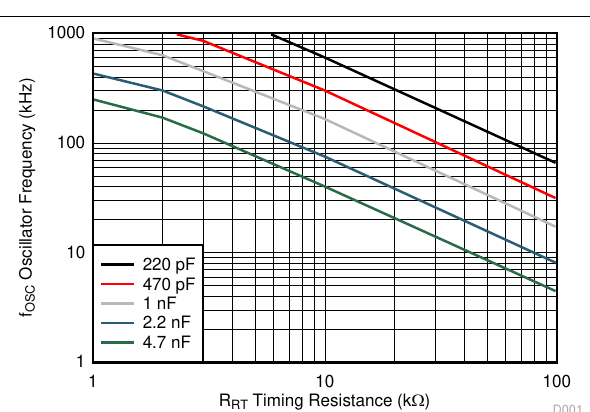

### DUTY vs Frequency

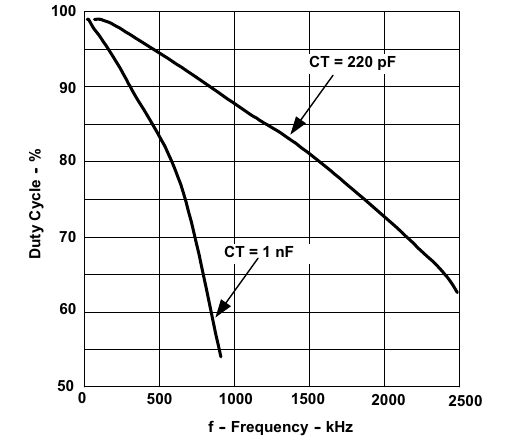

In [355]:
RT = 15.4e3
CT = 1e-9

print(f"RT: {EngFormatter(unit='Ω').format_data(RT)}")
print(f"CT: {EngFormatter(unit='F').format_data(CT)}")

print(f"Frequency by Datasheet: {EngFormatter(unit='Hz').format_data(110e3)}")

f_aprox = 1 / ( RT * CT)
print(f"\nFALSE Approximate Frequency (f_aprx): {EngFormatter(unit='Hz').format_data(f_aprox)}")

RT: 15.4 kΩ
CT: 1 nF
Frequency by Datasheet: 110 kHz

FALSE Approximate Frequency (f_aprx): 64.9351 kHz


### Initial VDD timing

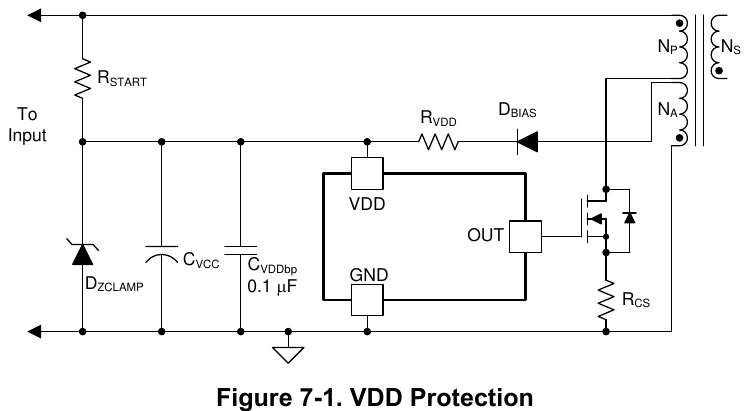

In [356]:
Rstart = 47e3
Cvddbp = 100e-9
Cvcc = 22e-6

tau = Rstart * (Cvddbp + Cvcc)
print(f"Time Constant (tau): {EngFormatter(unit='s').format_data(tau)}")    
print(f"Time to reach 99% of Vdd: {EngFormatter(unit='s').format_data(5*tau)}")

## Real startup time estimation
V_uvlo = 8.9  # Undervoltage lockout threshold in volt
V_bulk = 169.9        # Estimated bulk voltage in volts
t = tau * V_uvlo / V_bulk
print(f"V_uvlo/V_bulk: {V_uvlo/V_bulk}") # Percentage of the time constant that contributes to reaching the undervoltage lockout threshold.
print("\n----------\n")
print(f"Estimated Startup Time: {EngFormatter(unit='s').format_data(t)}")


Time Constant (tau): 1.0387 s
Time to reach 99% of Vdd: 5.1935 s
V_uvlo/V_bulk: 0.052383755150088286

----------

Estimated Startup Time: 54.411 ms


### Soft - start 1

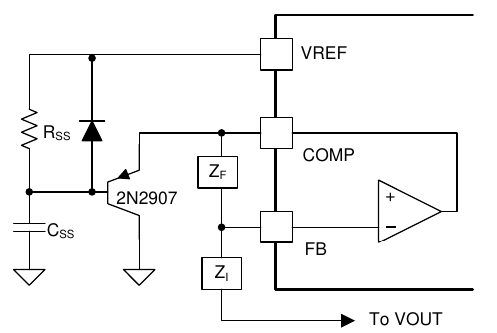

In [357]:
# Define parameters
tau = 20e-3 # Choosen by IA recomendation

Css = 1e-6
Rss = tau / (5* Css)
print(f"tau: {EngFormatter(unit='s').format_data(tau)}")
print(f"Rss: {EngFormatter(unit='Ω').format_data(Rss)}")
print(f"Css: {EngFormatter(unit='F').format_data(Css)}")


print("\n------------------------Calculating Pole------------------------")
# Se calcula para poner un polo de compensancion al lado primario del EA.
# Se elige R
# Zf 
Rcomp_p = 10e3

# Zero of Cout
R_esr_cout = 0.1 # ESR of the output capacitor in ohms
f_ESRz= 1 / (2 * np.pi * c_out * R_esr_cout) 
C_comp_p = 1 / (2 * np.pi * f_ESRz * Rcomp_p)

print(f"Compensation Pole Resistance (Rcomp_p): {EngFormatter(unit='Ω').format_data(Rcomp_p)}")
print(f"Compensation Pole Capacitance (C_comp_p): {EngFormatter(unit='F').format_data(C_comp_p)}")

tau: 20 ms
Rss: 4 kΩ
Css: 1 µF

------------------------Calculating Pole------------------------
Compensation Pole Resistance (Rcomp_p): 10 kΩ
Compensation Pole Capacitance (C_comp_p): 2.34885 nF


### Current Sensing and Overcurrent limit

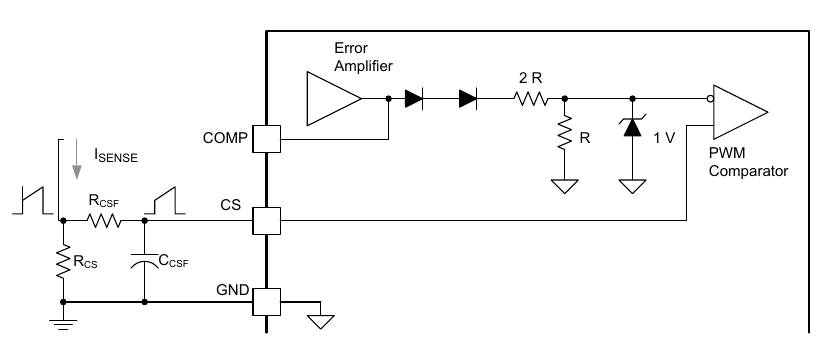

In [369]:
I_max_sensing = ipk
print("\n----------------------Current Sensing Design:-----------------------\n")
print(f"Maximum MOSFET current (Ipk): {EngFormatter(unit='A').format_data(ipk)} \n")

V_sense_max = Rcs * I_max_sensing
print(f"Maximum Sense Voltage (V_sense_max): {EngFormatter(unit='V').format_data(V_sense_max)}")

PRcs = (I_max_sensing**2) * Rcs
print(f"Power Dissipation in Rcs (PRcs): {EngFormatter(unit='W').format_data(PRcs)}")

## Filter 

print("\n----------------------Filter Design:-----------------------\n")
Rcsf = 3.11146e3
Ccsf = 0.1e-9
tau_filter = Rcsf * Ccsf

print(f"Rcsf: {EngFormatter(unit='Ω').format_data(Rcsf)}")
print(f"Ccsf: {EngFormatter(unit='F').format_data(Ccsf)}")

print("\nFilter Design Parameters:\n")

print(f"Filter Time Constant (tau_filter): {EngFormatter(unit='s').format_data(tau_filter)}")
print(f"Filter Cutoff Frequency (f_filter): {EngFormatter(unit='Hz').format_data(1/(2*math.pi*tau_filter))}")

Tsw = 1/f_sw
print(f"Switching Period (Tsw): {EngFormatter(unit='s').format_data(Tsw)}")

# Tsw >> tau_filter. At least 10 times.
print(f"Tsw / tau_filter: {Tsw / tau_filter:.2f} (should be at least > 10)")



----------------------Current Sensing Design:-----------------------

Maximum MOSFET current (Ipk): 2.54925 A 

Maximum Sense Voltage (V_sense_max): 1 V
Power Dissipation in Rcs (PRcs): 2.54925 W

----------------------Filter Design:-----------------------

Rcsf: 3.11146 kΩ
Ccsf: 100 pF

Filter Design Parameters:

Filter Time Constant (tau_filter): 311.146 ns
Filter Cutoff Frequency (f_filter): 511.512 kHz
Switching Period (Tsw): 9.09091 µs
Tsw / tau_filter: 29.22 (should be at least > 10)


In [359]:
## Optional Rp
# Sin Rp, Rcs da el pico maximo de corriente en el transformador bsandose en el pico de voltaje de CS (Suele ser 1V).
# Rcs se calcula como V_sense_max / I_max_sensing. 

# Ademas de problemas para el MOSFET y el transformador, se tendria mucha disipacion en esa resistencia.

V_sense_max = 1  # Maximum sense voltage in volts
I_max_sensing = Ipeak_sensed # Maximum current to be sensed, which is the peak current through the MOSFET

Rcs = V_sense_max / I_max_sensing # Sensor resistor value in ohms
print(f"Rcs: {EngFormatter(unit='Ω').format_data(Rcs)}")


PRcs = (I_max_sensing**2) * Rcs
print(f"Power Dissipation in Rcs (PRcs): {EngFormatter(unit='W').format_data(PRcs)}")  


# Se añade Rp para inyectar un voltaje de Offset en Cs. Se forma un divisor entre Rp y Rcsf desde la señal sendada por Rcs, hasta Vref.
print("\n----------------------Voltage Offset Design:-----------------------\n")
#V_offset = Rcsf/(Rcsf + Rp) * V_sense_max
V_offset_min = 0.05*(V_sense_max) # Desired voltage offset in volts
print(f"Desired Voltage Offset (V_offset_min): {EngFormatter(unit='V').format_data(V_offset_min)}")
Rp_min = Rcsf * (Vref / V_offset_min - 1)

V_offset_max = 0.15*(V_sense_max) # Desired voltage offset in volts
print(f"Desired Voltage Offset (V_offset_max): {EngFormatter(unit='V').format_data(V_offset_max)}\n")
Rp_max = Rcsf * (Vref / V_offset_max - 1)

print(f"Minimum Rp: {EngFormatter(unit='Ω').format_data(Rp_min)} to achieve a voltage offset of {EngFormatter(unit='V').format_data(V_offset_min)}")
print(f"Maximum Rp: {EngFormatter(unit='Ω').format_data(Rp_max)} to achieve a voltage offset of {EngFormatter(unit='V').format_data(V_offset_max)}")
# Revisar despues bien como funciona esto, porque depende es de aplicativo. 



Rcs: 392.272 mΩ
Power Dissipation in Rcs (PRcs): 2.54925 W

----------------------Voltage Offset Design:-----------------------

Desired Voltage Offset (V_offset_min): 50 mV
Desired Voltage Offset (V_offset_max): 150 mV

Minimum Rp: 325.673 kΩ to achieve a voltage offset of 50 mV
Maximum Rp: 106.365 kΩ to achieve a voltage offset of 150 mV


### Slope compensation

Da cosas raras. Se deja lo del datasheet.

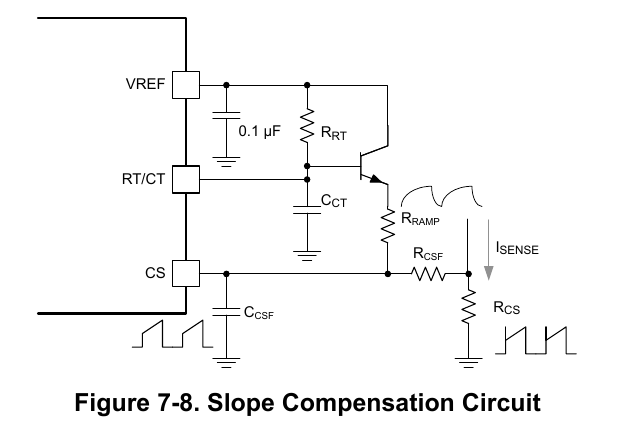

Sn → pendiente natural (corriente del inductor reflejada a CS)
Se → pendiente artificial (la que tú diseñas)
Mc → factor de compensación

Qp = 1 --> Sistema críticamente amortiguado (óptimo)



In [360]:
# =========================
# FACTOR IDEAL Mc
# =========================
def calc_Mc_ideal(D):
    return (1/np.pi + 0.5) / (1 - D)


# =========================
# PENDIENTE NATURAL (Sn)
# =========================
def calc_Sn(Vin_min, Rcs, Lp):
    return (Vin_min * Rcs) / Lp   # V/s


# =========================
# PENDIENTE DE COMPENSACIÓN (Se)
# =========================
def calc_Se(Mc, Sn):
    return (Mc - 1) * Sn


# =========================
# FACTOR Mc REAL
# =========================
def calc_Mc(Se, Sn):
    return Se / Sn + 1


# =========================
# Qp (calidad del sistema)
# =========================
def calc_Qp(Mc, D):
    return 1 / (np.pi * (Mc * (1 - D) - 0.5))


# =========================
# PENDIENTE DEL OSCILADOR (REAL IC)
# =========================
def calc_Sosc(Vosc_pp, D, f_sw):
    t_on_min = D / f_sw
    return Vosc_pp / t_on_min  # V/s


# =========================
# DISEÑO REAL: Rcsf
# =========================
def calc_Rcsf(Rramp, Sosc, Se):
    return Rramp / (Sosc / Se - 1)


# =========================
# DISEÑO REAL: Rramp
# =========================
def calc_Rramp_from_Rcsf(Rcsf, Sosc, Se):
    return Rcsf * (Sosc / Se - 1)


# =========================
# CRAMP (AC coupling)
# =========================
def calc_Cramp_default():
    return 10e-9  # 10nF recomendado datasheet

In [361]:
# =========================
# CALCULO TEORICO
# =========================

Mc_ideal = calc_Mc_ideal(D)
Sn = calc_Sn(V_IN_min, Rcs, lp)
Se = calc_Se(Mc_ideal, Sn)
Mc_real = calc_Mc(Se, Sn)
Qp = calc_Qp(Mc_real, D)

print(f"Ideal Mc: {Mc_ideal:.2f}")
print(f"Natural Slope (Sn): {EngFormatter(unit='V/s').format_data(Sn)}")
print(f"Compensation Slope (Se): {EngFormatter(unit='V/s').format_data(Se)}")
print(f"Real Mc: {Mc_real:.2f}")
print(f"Qp: {Qp:.2f}")

print(f"Is the system stable? {'Yes' if Se >= Sn/2 else 'No'}")


# =========================
# DISEÑO REAL (DATASHEET)
# =========================

print("\n----------------------Real Ramp Design (Datasheet-Based)-----------------------\n")

Vosc_pp = 1.9  # típico datasheet
Rramp = 24.9e3  # valor típico recomendado
Cramp = calc_Cramp_default()

Sosc = calc_Sosc(Vosc_pp, D, f_sw)

# Calculamos Rcsf real
Rcsf = calc_Rcsf(Rramp, Sosc, Se)

print(f"Oscillator Slope (Sosc): {EngFormatter(unit='V/s').format_data(Sosc)}")
print(f"Ramp Resistor (Rramp): {EngFormatter(unit='Ω').format_data(Rramp)}")
print(f"Ramp Capacitor (Cramp): {EngFormatter(unit='F').format_data(Cramp)}")
print(f"CS Filter Resistor (Rcsf): {EngFormatter(unit='Ω').format_data(Rcsf)}")


# =========================
# VALIDACION
# =========================

ratio = Sosc / Se

print("\n----------------------Validation-----------------------\n")
print(f"Sosc / Se ratio: {ratio:.2f} (should be > 1)")

Ideal Mc: 1.57
Natural Slope (Sn): 84.6231 kV/s
Compensation Slope (Se): 48.4163 kV/s
Real Mc: 1.57
Qp: 1.00
Is the system stable? Yes

----------------------Real Ramp Design (Datasheet-Based)-----------------------

Oscillator Slope (Sosc): 435.877 kV/s
Ramp Resistor (Rramp): 24.9 kΩ
Ramp Capacitor (Cramp): 10 nF
CS Filter Resistor (Rcsf): 3.11146 kΩ

----------------------Validation-----------------------

Sosc / Se ratio: 9.00 (should be > 1)


## Out


In [362]:
# Define parameters of output of the controller

Iout = Vout / RL
print(f"Output Current (Iout): {EngFormatter(unit='A').format_data(Iout)}")
print(f"Output Power (Pout): {EngFormatter(unit='W').format_data(Vout*Iout)}")



Output Current (Iout): 2.5 A
Output Power (Pout): 112.5 W



----
### Power stage Poles and Zeroes


In [363]:
def calc_Lp_crit(Rout, Nps, Vin, Vout, fsw):
    return (Rout * (Nps**2)) / (2 * fsw) * (Vin / (Vin + Vout * Nps))**2

In [364]:
# Must Lp > Lp_crit to ensure CCM operation.

Lp_crit = calc_Lp_crit(RL, Nps, V_bulk_typical, Vout, f_sw) #Peak Voltage not RMS.

print(f"Critical Primary Inductance (Lp_crit): {EngFormatter(unit='H').format_data(Lp_crit)}")  
print(f"Calculated Primary Inductance (Lp): {EngFormatter(unit='H').format_data(lp)}")
print(f"Is Lp > Lp_crit?: -->  {'CCM' if lp > Lp_crit else 'DCM'}")


Critical Primary Inductance (Lp_crit): 209.508 µH
Calculated Primary Inductance (Lp): 509.907 µH
Is Lp > Lp_crit?: -->  CCM


In [365]:
# Zero of Cout
R_esr_cout = 0.1 # ESR of the output capacitor in ohms

# ZERO RHP (limitante)
f_rhpz = (RL * (1 - D)**2 * (Nps**2)) / (2 * np.pi * lp * D)

# POLO DOMINANTE (salida)
tau_L = (2 * lp * f_sw) / (RL * (Nps**2))
f_p1 = ( ((1 - D)**3) / tau_L + (1 + D) ) / (2 * np.pi * RL * c_out)

# POLO ALTA FRECUENCIA
f_p2 = f_sw / 2

# ZERO POR ESR 
f_zero_cout = 1 / (2 * np.pi * c_out * R_esr_cout)

print(f"Zero Frequency of Cout (f_zero_cout): {EngFormatter(unit='Hz').format_data(f_zero_cout)}")
print(f"RHP Zero Frequency (f_RHPZ): {EngFormatter(unit='Hz').format_data(f_rhpz)}")
print(f"Dominant Pole Frequency (f_p1): {EngFormatter(unit='Hz').format_data(f_p1)}")
print(f"High-Frequency Pole (f_p2): {EngFormatter(unit='Hz').format_data(f_p2)}")


Zero Frequency of Cout (f_zero_cout): 6.77587 kHz
RHP Zero Frequency (f_RHPZ): 24.8313 kHz
Dominant Pole Frequency (f_p1): 62.3564 Hz
High-Frequency Pole (f_p2): 55 kHz


In [366]:
# Duty cycle (Ecuación 20)
def calc_D(Nps, Vout, Vbulk_min):
    return (Nps * Vout) / (Vbulk_min + (Nps * Vout))


# Parámetro M (Ecuación 22)
def calc_M(Vout, Nps, Vbulk_min):
    return (Vout * Nps) / Vbulk_min


# Tau_L (Ecuación 21)
def calc_tau_L(Lp, fsw, Rout, Nps):
    return (2 * Lp * fsw) / (Rout * (Nps**2))


# Ganancia DC (Ecuación 19)
def calc_G0(Rout, Nps, Rcs, Acs, D, tau_L, M):
    denominator = ((1 - D)**2) / tau_L + (2 * M) + 1
    return (Rout * Nps) / (Rcs * Acs) * (1 / denominator)

In [367]:
Acs = 3 # Gain of the current sense amplifier datasheet.

M = calc_M(Vout, Nps, V_BULK_min)
print(f"Parameter M: {EngFormatter(unit='').format_data(M)}")

tau_L= calc_tau_L(lp, f_sw, RL, Nps)
print(f"Tau_L: {EngFormatter(unit='s').format_data(tau_L)}")

D = calc_D(Nps, Vout, V_BULK_min)
print(f"Duty Cycle (D): {EngFormatter(unit='').format_data(D)}")

G0 = calc_G0(RL, Nps, Rcs, Acs, D, tau_L, M)
print(f"DC Gain (G0): {EngFormatter(unit='').format_data(G0)}")
print(f"DC Gain (G0) in dB: {20 * np.log10(G0):.2f} dB")

#Rout → Vout / Iout
#Nps  → N_primary / N_secondary
#Vbulk_min → voltaje DC mínimo después del rectificador
#Rcs  → resistencia de sensado
#Acs  → ganancia del amplificador de corriente (≈1 si no hay amplificador externo)
#Lp   → inductancia de magnetización
#fsw  → frecuencia de switching



Parameter M: 907.094 m
Tau_L: 796.734 ms
Duty Cycle (D): 475.642 m
DC Gain (G0): 13.5406
DC Gain (G0) in dB: 22.63 dB


### Bode


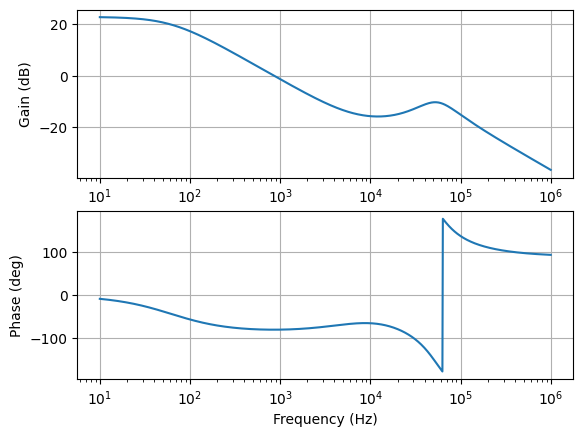

In [368]:
import matplotlib.pyplot as plt

# =========================
# Transfer function
# =========================
def H_open(f, G0, f_p1, f_p2, f_rhpz, f_esr, Qp):
    w = 2 * np.pi * f
    
    wp1 = 2 * np.pi * f_p1
    wp2 = 2 * np.pi * f_p2
    wrhpz = 2 * np.pi * f_rhpz
    wesr = 2 * np.pi * f_esr
    
    s = 1j * w
    
    num = (1 + s / wesr) * (1 - s / wrhpz)
    den1 = (1 + s / wp1)
    den2 = (1 + s / (wp2 * Qp) + (s / wp2)**2)
    
    return G0 * num / (den1 * den2)


# =========================
# Frecuencia
# =========================
f = np.logspace(1, 6, 1000)  # 10 Hz → 1 MHz

# =========================
# Evalúa la planta
# =========================
H = H_open(f, G0, f_p1, f_p2, f_rhpz, f_zero_cout, Qp)

gain = 20 * np.log10(np.abs(H))
phase = np.angle(H, deg=True)

# =========================
# Plot Bode
# =========================
plt.figure()

# Ganancia
plt.subplot(2,1,1)
plt.semilogx(f, gain)
plt.ylabel("Gain (dB)")
plt.grid(True)

# Fase
plt.subplot(2,1,2)
plt.semilogx(f, phase)
plt.ylabel("Phase (deg)")
plt.xlabel("Frequency (Hz)")
plt.grid(True)

plt.show()

### Rled xd
